Title: SEM_application_ERA5_yearly.ipynb

Purpose: Apply the simple energy model to the preprocessed ERA5 data

Author: Onno Nennecke on 19.03.2025 Modified: 16.12.2025

Input data: 

- Preprocessed ERA5 Data 
    - This file lies here: '/climca/people/onennecke/not_debiased_data/'
- Installed capacity grids: wind_offshore_ic_{year}.nc, wind_onshore_ic_{year}.nc, solar_ic_netto_{year}.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/
- Wind hub height grids: wind_offshore_height_weighted_{year}.nc, wind_onshore_height_weighted_{year}.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/ 
- Regridded population data: population_regrid_weights.nc
    - This file lies here: /climca/people/onennecke/population_data/
- Fit values from vdW Paper: demand_fit_values_week.nc
    - This file lies here: /climca/people/onennecke/population_data/

Output data:

- Timeseries of production, demand and RL
    - This file lies here: f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries.nc'
    - Bias corrected (Not used): (This file lies here: f'/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/{ESM}_{run}_timeseries.nc')

### Load libraries and functions

In [1]:
import gc

In [2]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Define variables (all in the config file)


```python
Wind:
- alpha_on = 1/7    # Roughness parameter onshore  
- alpha_off = 0.11  # Roughness parameter offshore  
- ref_height = 100   # Height of wind data  
- v_cutin = 3.5     # Minimum wind speed to start producing power  
- v_cutout = 25     # Maximum wind speed to produce power  
- v_rated = 13      # Wind speed at which the turbine produces maximum power  
- time_oper = 24    # operational time of hub [h/day]  
- Hub Height:
    - # hub_height_on = 80    # Approximation: Onshore 80 m --> Bad Approximation --> Used own grid data instead  
    - # hub_height_off = 120  # Approximation: Offshore 120 m --> Bad Approximation --> Used own grid data instead  

Solar:

- cT_c1 = 4.3       # constant [dC]  
- cT_c2 = 0.943     # constant [-]  
- cT_c3 = 0.028     # constant [dC m2 W-1]  
- cT_c4 = -1.528    # constant [dC s m-1]  
- gamma = -0.005    # constant [--]  
- temp_ref = 25     # reference temperature [dC]  
- gstc = 1000       # standard test conditions [W m-2]  
- shift_doy = 186   # if HadGEM : 180  
```

### Load datasets

In [3]:
years = range(2015, 2025)

grid_offshore = {}
grid_onshore = {}
grid_offshore_hh = {}
grid_onshore_hh = {}
grid_solar = {}

for year in years:
    grid_offshore_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_{year}.nc')
    grid_offshore[year] = grid_offshore_temp['wind_off_cap']
    grid_onshore_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic_{year}.nc')
    grid_onshore[year] = grid_onshore_temp['wind_on_cap']
    grid_solar_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_{year}.nc')
    grid_solar[year] = grid_solar_temp['solar_cap']
    grid_offshore_hh_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_{year}.nc')
    grid_offshore_hh[year] = grid_offshore_hh_temp['wind_off_hub_height']
    grid_onshore_hh_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted_{year}.nc')
    grid_onshore_hh[year] = grid_onshore_hh_temp['wind_on_hub_height']



In [4]:
mask_offshore = xr.where(np.isfinite(grid_offshore[2024]), 1, 0)
mask_onshore = xr.where(np.isfinite(grid_onshore[2024]), 1, 0)
mask_solar = xr.where(np.isfinite(grid_solar[2024]), 1, 0)

In [5]:
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [6]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

### Define used models

In [7]:
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = era5_row
used_runs['Ref'] = 1

used_runs

,ESM,Institution,run,Ref
0,ERA5,ECMWF,hist,1


### Run SEM

In [8]:
run_time = time.time()
ESM = used_runs['ESM'][0]
Inst = used_runs['Institution'][0]
run = used_runs['run'][0]
print(f'Processing Run Nr. {0+1}, {ESM}, {Inst}, {run}, \n')
# base_path = '/climca/people/onennecke/debiased_data/'
base_path = '/climca/people/onennecke/not_debiased_data/'

sel_run = glob.glob(os.path.join(base_path, f"{ESM}_{run}_*"))

# now drop any psl files
sel_run = [fn for fn in sel_run if '_psl' not in os.path.basename(fn)]
# print(sel_run)
combined_ds = xr.open_mfdataset(sel_run)
combined_ds = combined_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
# Filter to only winter months (October to March)
# combined_ds = combined_ds.sel(time=combined_ds.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

combined_ds['tas'] = combined_ds['tas'] - 273.15 # Convert temperature from Kelvin to Celsius
combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15 # Convert maximum temperature from Kelvin to Celsius


Processing Run Nr. 1, ERA5, ECMWF, hist, 



In [9]:
years = range(2015, 2025)

ts_list = []          # weekly / standard demand
ts_list_wwd = []      # weekday/weekend variant (optional)


for year in years:
    print(f"\n=== Processing year {year} ===")
    run_time = time.time()

    # 1) slice the big combined dataset to this calendar year
    ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()
    # if ds_year.time.size == 0:
    #     print(f"  -> no timesteps for {year}, skipping")
    #     continue

    # 2) optional: quick check that the grids align with ds coords (lat/lon)
    # If they don't align, you should regrid/interp the capacity grids to ds_year lat/lon.
    # Simple check:
    # def coords_match(a, b, dim="lat"):
    #     return set(a[dim].values) == set(b[dim].values)

    # # Example: if grid coords don't match, alert (you'll probably want to reproject/interp)
    # if not coords_match(ds_year, grid_offshore_hh[year], dim="lat") or not coords_match(ds_year, grid_offshore_hh[year], dim="lon"):
    #     print("  WARNING: offshore hub-height grid coords don't match ds_year coords. "
    #           "Consider regridding (xr.interp / xESMF) to align them.")

    # 3) compute wind potential using year-specific hub heights
    ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')
    
    # wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], config.a_offshore, config.height_ref)
    # wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref)
    wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], 
                                                              config.a_offshore, config.height_ref, v_cutin=config.v_cutin0_off_unb, 
                                                              v_rated=config.v_rated0_off_unb, v_cutout=config.v_cutout0_off_unb)
    wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, 
                                                             config.height_ref, v_cutin=config.v_cutin0_on_weighted, 
                                                             v_rated=config.v_rated0_on_weighted, v_cutout=config.v_cutout0_on_weighted)

    
    ds_year['wind_off_pot'] = wepot_off['pot']
    ds_year['wind_on_pot']  = wepot_on['pot']

    # 4) compute energy production using year-specific capacity maps
    weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore[year])
    weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on,  grid_onshore[year])

    ds_year['wind_off_prod'] = weprod_off['prod']
    ds_year['wind_on_prod']  = weprod_on['prod']

    # 5) solar potential & production with year-specific solar capacity
    # sepot = solar_model_func.compute_solar_energy_potential(ds_year['rsds'], ds_year['tas'], ds_year['tasmax'], ds_year['sfcWind'])
    sepot = solar_model_func.compute_solar_energy_potential(ds_year['rsds'], ds_year['tas'], ds_year['tasmax'], 
                                                            ds_year['sfcWind'], constants=config.pv_constants_unb, 
                                                            gamma=config.gamma_unb, ref_temp=config.temp_ref_unb)
    ds_year['solar_pot'] = sepot
    seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar[year])
    ds_year['solar_prod'] = seprod

    # 6) population-weighted temperature time series for this year
    # (since ds_year contains only this year, we don't need the previous "loop over unique years")
    ds_weighted_temp = xr.Dataset()
    # sum over lat/lon weighted by population regridded weights
    ds_weighted_temp['temp'] = (ds_year['tas'] * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])

    # 7) demand (weekly fit) for this year's weighted temp
    demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country=9, period='week'))
    timeseries_ds = demand_ds.copy()

    # 8) build timeseries aggregates (masked area means + production sums)
    timeseries_ds['sfcWind'] = ds_year['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['rsds']    = ds_year['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tas']     = ds_year['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tasmax']  = ds_year['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

    timeseries_ds['wind_off_prod'] = ds_year['wind_off_prod'].sum(dim=['lat', 'lon']) / 1_000_000
    timeseries_ds['wind_on_prod']  = ds_year['wind_on_prod'].sum(dim=['lat', 'lon'])  / 1_000_000
    timeseries_ds['solar_prod']    = ds_year['solar_prod'].sum(dim=['lat', 'lon'])      / 1_000_000

    timeseries_ds['total_prod']     = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
    timeseries_ds['Netto']          = timeseries_ds['total_prod'] - timeseries_ds['demand']
    timeseries_ds['Residual_load']  = timeseries_ds['demand'] - timeseries_ds['total_prod']

    # 9) assign coords / metadata and save per-year
    ts_output = timeseries_ds.assign_coords(run='hist', ESM='ERA5_week', ESM_run='ERA5_hist_week')


    ts_output.load()  # ensure in-memory before writing
    # outpath = f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries_{year}.nc'
    # ts_output.to_netcdf(outpath)
    # print(f'  -> wrote timeseries to {outpath}')
    # print('  Run time: ', int(np.floor((time.time() - run_time) / 60)), 'm', round((time.time() - run_time) % 60, 1), 's')

    ts_output = timeseries_ds.assign_coords(
        run=run if ESM != "ERA5" else "hist",
        ESM=ESM,
        ESM_run=f"{ESM}_{run}",
    )

    # Ensure clean time axis (important!)
    ts_output = ts_output.sortby("time")

    ts_list.append(ts_output)
    
    # 10) weekday/weekend demand variant (wwd)
    ds_weighted_temp_w = xr.concat(
        [
            ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] < 5, drop=True),
            ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] >= 5, drop=True),
        ],
        "period",
    )
    ds_weighted_temp_w["period"] = ["weekday", "weekend"]
    ds_weighted_temp_w.load()

    demand_weekday = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekday'), demand_fit_values.sel(country=9, period='weekday'))
    demand_weekend = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekend'), demand_fit_values.sel(country=9, period='weekend'))
    demand_ds_wwd = (demand_weekday).fillna(0) + (demand_weekend).fillna(0)

    timeseries_ds = demand_ds_wwd.copy()
    timeseries_ds['sfcWind'] = ds_year['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['rsds']    = ds_year['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tas']     = ds_year['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tasmax']  = ds_year['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

    timeseries_ds['wind_off_prod'] = ds_year['wind_off_prod'].sum(dim=['lat', 'lon']) / 1_000_000
    timeseries_ds['wind_on_prod']  = ds_year['wind_on_prod'].sum(dim=['lat', 'lon'])  / 1_000_000
    timeseries_ds['solar_prod']    = ds_year['solar_prod'].sum(dim=['lat', 'lon'])      / 1_000_000
    timeseries_ds['total_prod']    = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
    timeseries_ds['Netto']         = timeseries_ds['total_prod'] - timeseries_ds['demand']
    timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

    ts_output = timeseries_ds.assign_coords(run='hist', ESM=f'{ESM}_wwd', ESM_run=f'{ESM}_hist_wwd', period='wwd')
    ts_output.load()
    # outpath_wwd = f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_timeseries_wwd_{year}.nc'
    # ts_output.to_netcdf(outpath_wwd)
    # print(f'  -> wrote weekday/weekend timeseries to {outpath_wwd}')
    # print('  Run time: ', int(np.floor((time.time() - run_time) / 60)), 'm', round((time.time() - run_time) % 60, 1), 's')
    
    ts_output_wwd = timeseries_ds.assign_coords(
        run="hist",
        ESM=f"{ESM}_wwd",
        ESM_run=f"{ESM}_hist_wwd",
        period="wwd",
    )

    ts_output_wwd = ts_output_wwd.sortby("time")
    ts_list_wwd.append(ts_output_wwd)


    # 11) cleanup
    del ds_year, ds_weighted_temp, ds_weighted_temp_w, timeseries_ds, ts_output
    gc.collect()
    
ts_full = xr.concat(ts_list, dim="time")

# safety: remove duplicate timestamps if any
_, index = np.unique(ts_full["time"], return_index=True)
ts_full = ts_full.isel(time=index)

ts_full.load()
ts_full.to_netcdf(f"/climca/people/onennecke/model_output/not_bias_corrected/ERA5_yearly/{ESM}_{run}_timeseries_yearly.nc")


ts_full_wwd = xr.concat(ts_list_wwd, dim="time")

_, index = np.unique(ts_full_wwd["time"], return_index=True)
ts_full_wwd = ts_full_wwd.isel(time=index)

ts_full_wwd.load()
ts_full_wwd.to_netcdf(f"/climca/people/onennecke/model_output/not_bias_corrected/ERA5_yearly/{ESM}_timeseries_wwd_yearly.nc")
print(ts_full.time.min().values, ts_full.time.max().values)
print(ts_full.dims)

ts_full



=== Processing year 2015 ===

=== Processing year 2016 ===

=== Processing year 2017 ===

=== Processing year 2018 ===

=== Processing year 2019 ===

=== Processing year 2020 ===

=== Processing year 2021 ===

=== Processing year 2022 ===

=== Processing year 2023 ===

=== Processing year 2024 ===
2015-01-01T00:00:00.000000000 2024-12-31T00:00:00.000000000
FrozenMappingWarningOnValuesAccess({'time': 3650})


<xarray.Dataset> Size: 321kB
Dimensions:        (time: 3650)
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U4 16B 'ERA5'
    run            <U4 16B 'hist'
    ESM_run        <U9 36B 'ERA5_hist'
    country        float64 8B 9.0
    period         <U7 28B 'week'
Data variables:
    temp           (time) float64 29kB 1.323 3.335 2.591 ... 0.7396 0.4142
    demand         (time) float64 29kB 1.504e+03 1.479e+03 ... 1.515e+03
    sfcWind        (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds           (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas            (time) float32 15kB 1.771 3.587 3.046 ... 0.2238 1.512 1.194
    tasmax         (time) float32 15kB 3.431 5.871 4.704 ... 2.446 2.709 3.361
    wind_off_prod  (time) float64 29kB 81.14 81.17 81.17 ... 140.7 221.1 221.1
    wind_on_prod   (time) float64 29kB 388.2 796.9 559.3 ... 349.6 783.9 831.2
    solar_prod     (time) float64 29kB 21.88 10.73 10.6 ... 53.04 48.64 59.86
    total_prod     (time) float64 29kB 491.2 888.8 651.0 ... 1.054e+03 1.112e+03
    Netto          (time) float64 29kB -1.012e+03 -589.9 ... -457.1 -402.6
    Residual_load  (time) float64 29kB 1.012e+03 589.9 836.8 ... 457.1 402.6

#### Some plots to check everything is alright

In [10]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

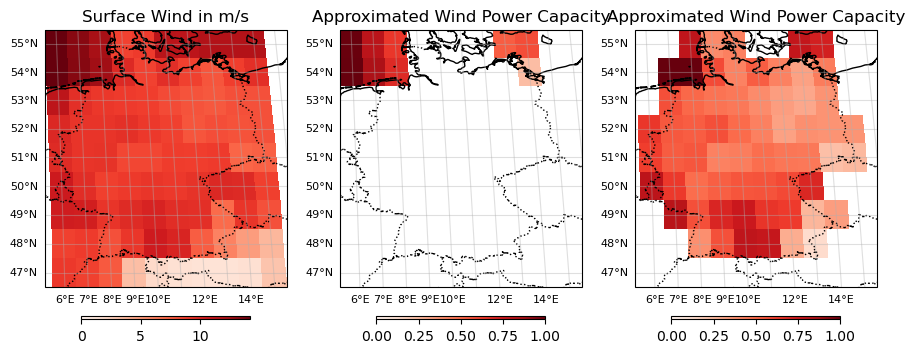

In [11]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values
lat_edges = combined_ds['lat'].values

vmin = 0 
vmax = 1

# Plot the data
timestep = -10 # 201

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['sfcWind'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax3)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')

plt.tight_layout()
plt.show()

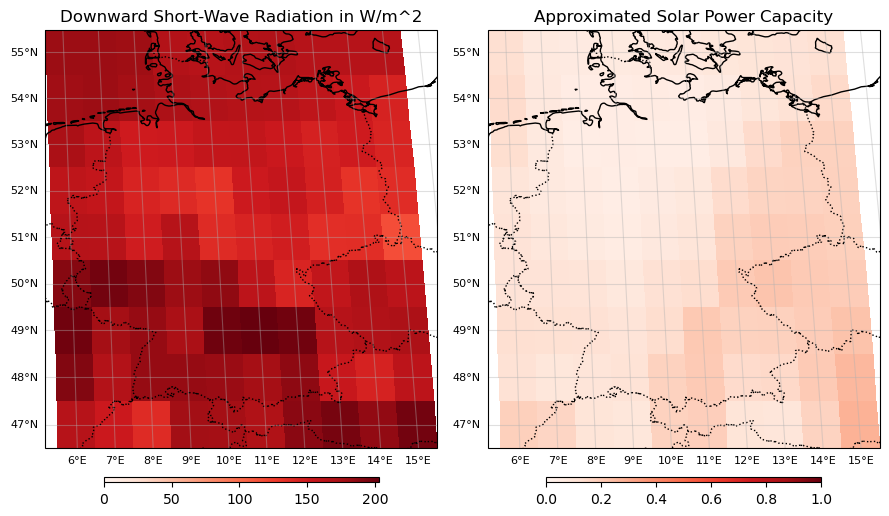

In [12]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot#.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 90# 29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

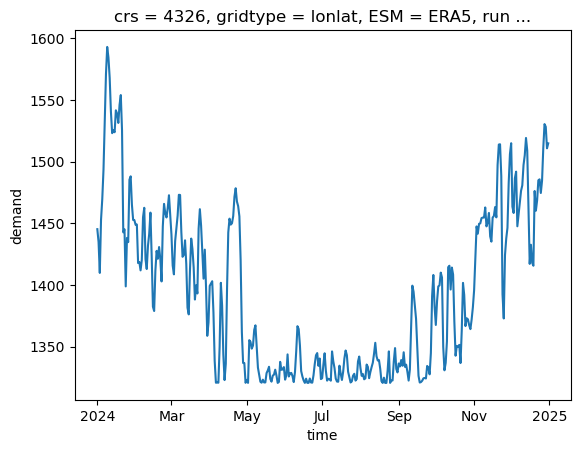

In [13]:
demand_ds['demand'][0:365].plot()

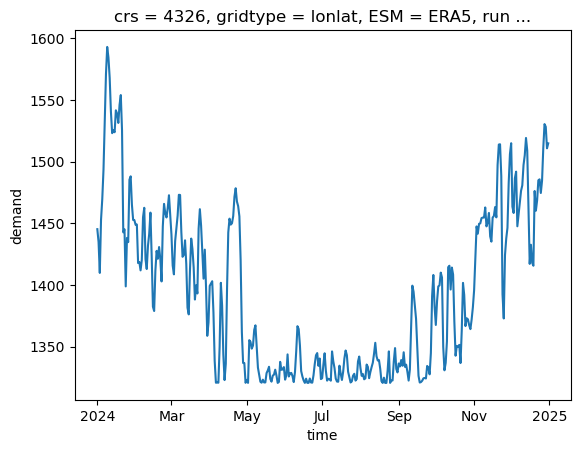

In [14]:
demand_ds['demand'][0:365].plot()

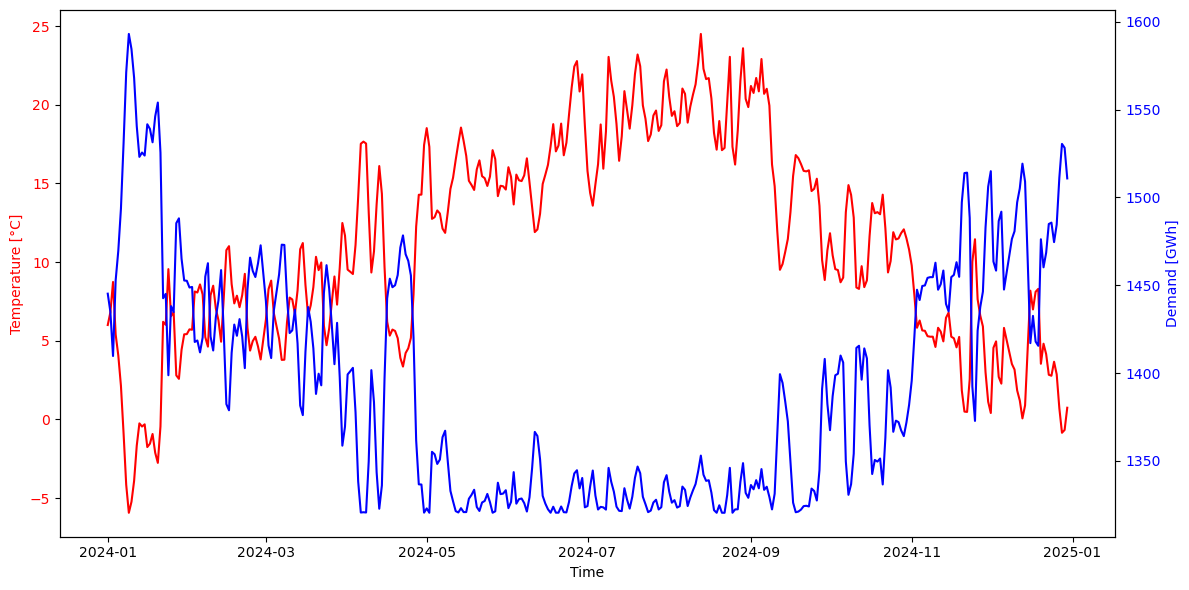

In [15]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots(figsize=(12, 6))

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')
# ax2.set_ylim(1000, 2200)  # Adjust y-axis limits for demand

fig.tight_layout()
plt.show()

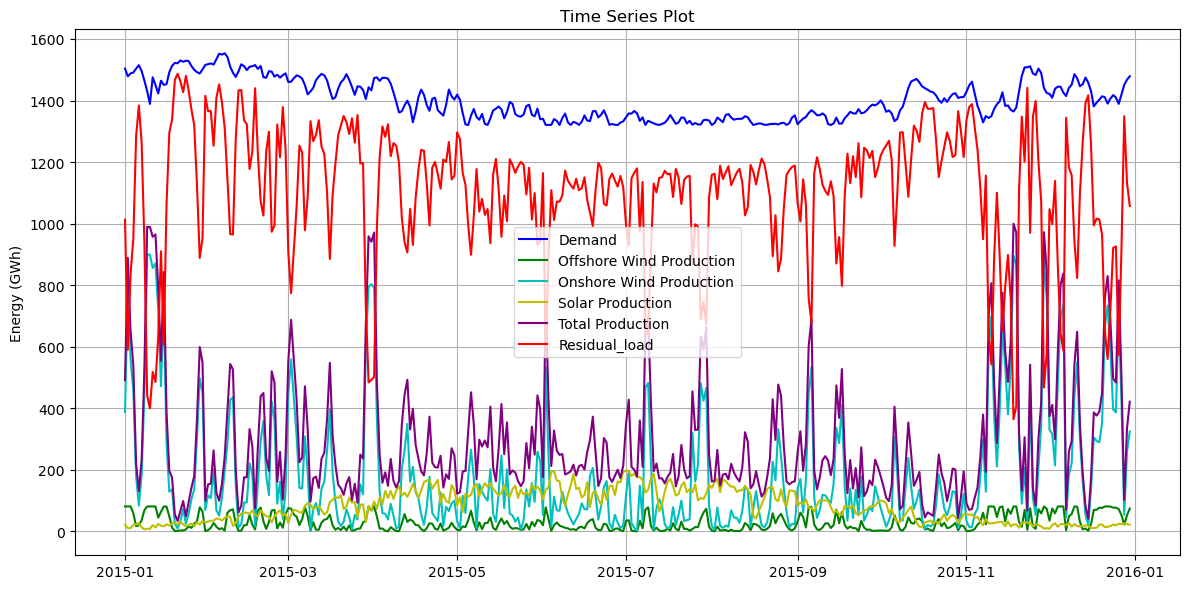

In [16]:
# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 0
b = 364
# a = 365
# b = 365 * 2

# Extract time and variables for the chosen range
time = ts_full['time'][a:b]
demand = ts_full['demand'][a:b]
wind_off = ts_full['wind_off_prod'][a:b]
wind_on = ts_full['wind_on_prod'][a:b]
solar = ts_full['solar_prod'][a:b]
total_prod = ts_full['total_prod'][a:b]
Residual_load = ts_full['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()